In [3]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

Text(0, 0.5, 'Y dataset')

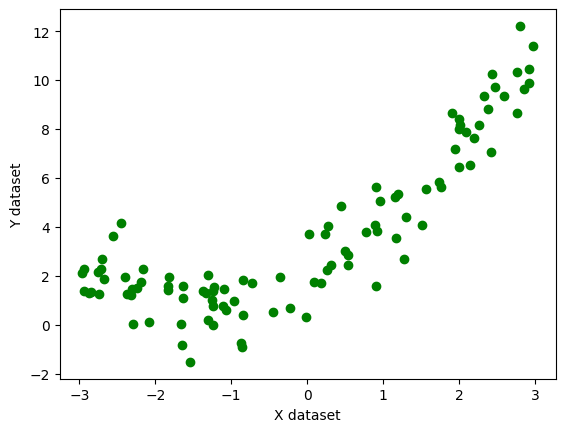

In [4]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [7]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.6497511640295173


Text(0, 0.5, 'Y')

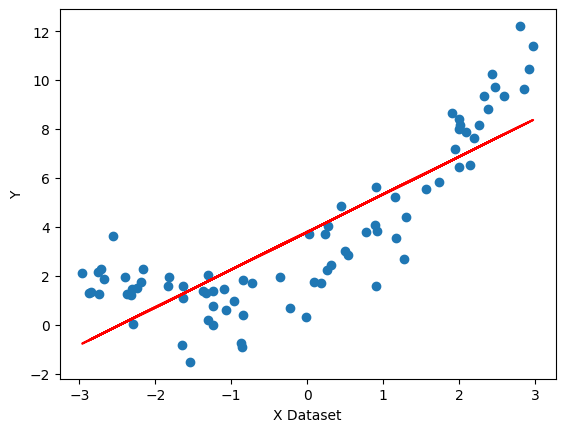

In [9]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")


In [10]:
#LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [11]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [12]:
X_train_poly

array([[ 1.00000000e+00, -2.68040810e+00,  7.18458759e+00],
       [ 1.00000000e+00, -2.96269215e+00,  8.77754478e+00],
       [ 1.00000000e+00,  4.98761037e-01,  2.48762572e-01],
       [ 1.00000000e+00, -1.63743154e+00,  2.68118206e+00],
       [ 1.00000000e+00,  1.73875985e+00,  3.02328583e+00],
       [ 1.00000000e+00,  2.80186648e+00,  7.85045576e+00],
       [ 1.00000000e+00,  1.30075414e+00,  1.69196133e+00],
       [ 1.00000000e+00,  1.90904508e+00,  3.64445310e+00],
       [ 1.00000000e+00, -1.65230714e+00,  2.73011889e+00],
       [ 1.00000000e+00, -7.24749323e-01,  5.25261581e-01],
       [ 1.00000000e+00, -2.87704487e+00,  8.27738718e+00],
       [ 1.00000000e+00,  1.57226247e+00,  2.47200926e+00],
       [ 1.00000000e+00, -1.08857548e+00,  1.18499657e+00],
       [ 1.00000000e+00,  9.21859257e-01,  8.49824490e-01],
       [ 1.00000000e+00, -2.29072863e-01,  5.24743767e-02],
       [ 1.00000000e+00, -2.23512954e+00,  4.99580407e+00],
       [ 1.00000000e+00, -2.74375685e+00

In [13]:
X_test_poly

array([[ 1.        , -2.08260797,  4.33725597],
       [ 1.        , -1.83135704,  3.3538686 ],
       [ 1.        , -1.23283808,  1.51988974],
       [ 1.        , -2.70259377,  7.30401311],
       [ 1.        , -1.66221744,  2.76296682],
       [ 1.        ,  2.92243142,  8.54060542],
       [ 1.        , -0.45099905,  0.20340014],
       [ 1.        ,  1.50951784,  2.2786441 ],
       [ 1.        ,  2.76433493,  7.64154763],
       [ 1.        , -1.101706  ,  1.2137561 ],
       [ 1.        , -1.25048527,  1.56371341],
       [ 1.        ,  0.95592313,  0.91378902],
       [ 1.        , -2.94291336,  8.66073907],
       [ 1.        ,  2.7593349 ,  7.61392911],
       [ 1.        ,  1.19911005,  1.43786491],
       [ 1.        , -2.45544673,  6.02921864],
       [ 1.        ,  2.42612822,  5.88609814],
       [ 1.        ,  1.76197544,  3.10455745],
       [ 1.        ,  0.54339364,  0.29527665],
       [ 1.        , -2.93730497,  8.62776047]])

In [14]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8651735629306585


In [15]:
print(regression.coef_)

[[0.         1.56810045 0.56027321]]


In [16]:
print(regression.intercept_)

[1.96852846]


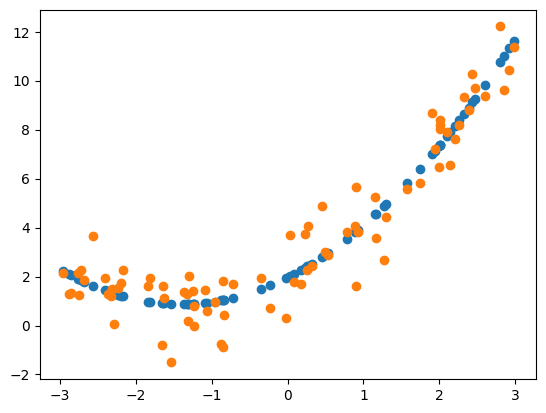

In [17]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [18]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [19]:
X_train_poly

array([[ 1.00000000e+00, -2.68040810e+00,  7.18458759e+00,
        -1.92576268e+01],
       [ 1.00000000e+00, -2.96269215e+00,  8.77754478e+00,
        -2.60051630e+01],
       [ 1.00000000e+00,  4.98761037e-01,  2.48762572e-01,
         1.24073078e-01],
       [ 1.00000000e+00, -1.63743154e+00,  2.68118206e+00,
        -4.39025207e+00],
       [ 1.00000000e+00,  1.73875985e+00,  3.02328583e+00,
         5.25676804e+00],
       [ 1.00000000e+00,  2.80186648e+00,  7.85045576e+00,
         2.19959288e+01],
       [ 1.00000000e+00,  1.30075414e+00,  1.69196133e+00,
         2.20082571e+00],
       [ 1.00000000e+00,  1.90904508e+00,  3.64445310e+00,
         6.95742526e+00],
       [ 1.00000000e+00, -1.65230714e+00,  2.73011889e+00,
        -4.51099494e+00],
       [ 1.00000000e+00, -7.24749323e-01,  5.25261581e-01,
        -3.80682975e-01],
       [ 1.00000000e+00, -2.87704487e+00,  8.27738718e+00,
        -2.38144143e+01],
       [ 1.00000000e+00,  1.57226247e+00,  2.47200926e+00,
      

In [20]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8680681778982348


In [21]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

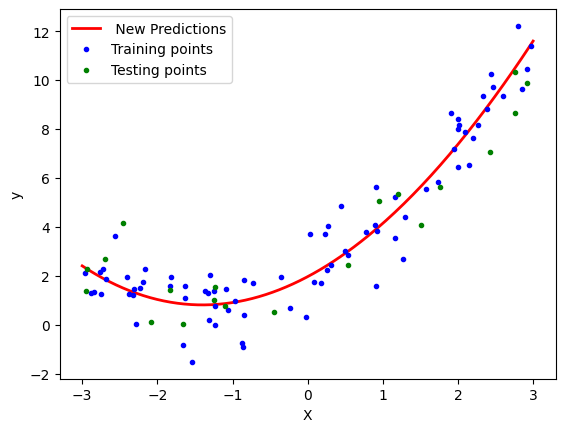

In [22]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts 

In [34]:
from sklearn.pipeline import Pipeline

In [46]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

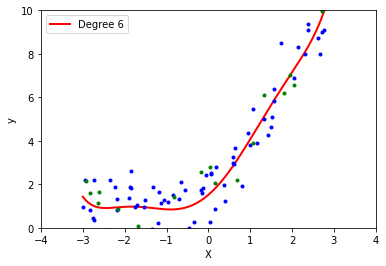

In [53]:
poly_regression(6)